# Importations:

In [1]:
# add folder to the path by uncommenting the script
# import sys
# sys.path.append("..")
# print("project folder added to the path")

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer


import src.preprocessing
import src.feature_engineering
import src.visualization
import src.modeling
import utils.preprocessing
import utils.feature_engineering
import utils.visualization
import utils.modeling
import utils.eda

print("✅importation successful.")

✅importation successful.


In [3]:
from numpy import __version__ as np_version
from pandas import __version__ as pd_version
from seaborn import __version__ as sns_version
from matplotlib import __version__ as plt_version
from sklearn import __version__ as sklearn_version

print(f"Scikit-learn's Version: {sklearn_version}")
print(f"NumPy's Version: {np_version}")
print(f"Pandas's Version: {pd_version}")
print(f"Seaborn's Version: {sns_version}")
print(f"Matploblib's Version: {plt_version}")

Scikit-learn's Version: 1.9.0
NumPy's Version: 2.4.2
Pandas's Version: 3.0.0
Seaborn's Version: 0.13.2
Matploblib's Version: 3.10.8


In [4]:
sns.set_theme(
    context="notebook",
    style="darkgrid"
)

# Project Introduction

This project investigates relationships between AI usage behaviors and GPA changes among students. The goal of the project is to uncover the hidden patterns in the data using EDA and training a regression model to predict the post_semester_gpa of the students.

In [5]:
raw_df = pd.read_csv("../data/raw/ai_student_impact_dataset (1).csv")

print(f"Samples: {raw_df.shape[0]}, Features: {raw_df.shape[1]}")
raw_df.head()

Samples: 50000, Features: 16


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


📁 **AI_Student_Impact_Dataset**:

🪪 `Identifier:` Student_ID

🎓 `Academic Profile:` Major_Category, Year_of_Study, Pre/Post GPA

🤖 `AI Behaviour:` Weekly_GenAI_Hours, Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity, Paid_Subscription

📚 `Study Habits:` Traditional_Study_Hours, Perceived_AI_Dependency

🏛️ `Institutional:` Institutional_Policy

🧠 `Well-being:` Anxiety_Level, Skill_Retention_Score, Burnout_Risk_Level

This is a clean dataset and there is no missing values, duplicates and irregularities in the data based-on the data descriptions in the Kaggle.

first we need to remove Student_ID and creating a new variable named GPA difference and then we can continue our work.

In [6]:
df = src.preprocessing.process_data(raw_df)

# saving data in the compressed numpy format
np.savez_compressed(file="../data/raw/data.npz", data=df, columns=df.columns)

df.head(10)

,student_id,major_category,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy,anxiety_level_during_exams,post_semester_gpa,skill_retention_score,burnout_risk_level,gpa_difference
0,100001,humanities,senior,2.418,23.31,copywriting/drafting,beginner,1,True,8.13,5,allowed_with_citation,6,2.393,86.44,high,-0.025
1,100002,medical,junior,3.821,1.12,ideation,advanced,5,False,16.65,3,allowed_with_citation,9,3.696,69.39,low,-0.125
2,100003,business,freshman,3.398,21.26,summarizing_reading,beginner,2,False,10.35,5,strict_ban,9,3.499,73.93,medium,0.101
3,100004,business,senior,3.789,1.82,copywriting/drafting,intermediate,4,False,15.23,2,allowed_with_citation,2,4.0,63.58,medium,0.211
4,100005,stem,sophomore,3.635,9.29,debugging/troubleshooting,advanced,4,False,12.55,4,allowed_with_citation,4,3.798,100.00,medium,0.163
5,100006,stem,junior,3.449,6.50,debugging/troubleshooting,beginner,1,False,14.19,4,allowed_with_citation,5,3.666,65.92,high,0.217
6,100007,stem,freshman,3.622,31.41,summarizing_reading,advanced,5,True,13.11,8,allowed_with_citation,7,4.0,67.97,medium,0.378
7,100008,arts,junior,2.746,5.33,copywriting/drafting,intermediate,3,False,18.45,2,actively_encouraged,1,2.965,85.09,medium,0.219
8,100009,business,sophomore,3.42,2.00,debugging/troubleshooting,beginner,2,True,2.87,1,strict_ban,5,3.396,55.71,medium,-0.024
9,100010,business,sophomore,3.046,19.99,debugging/troubleshooting,intermediate,2,True,12.49,3,strict_ban,8,2.978,87.18,high,-0.068


In [7]:
print("-" * 50)
print("Columns Info:")
print("-" * 50)
df.info()

--------------------------------------------------
Columns Info:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   student_id                  50000 non-null  object  
 1   major_category              50000 non-null  category
 2   year_of_study               50000 non-null  category
 3   pre_semester_gpa            50000 non-null  object  
 4   weekly_genai_hours          50000 non-null  float64 
 5   primary_use_case            50000 non-null  category
 6   prompt_engineering_skill    50000 non-null  category
 7   tool_diversity              50000 non-null  int64   
 8   paid_subscription           50000 non-null  bool    
 9   traditional_study_hours     50000 non-null  float64 
 10  perceived_ai_dependency     50000 non-null  int64   
 11  institutional_policy       

In [8]:
categorical_features, numerical_features = src.preprocessing.separate_features(df)

utils.eda.describe(df[numerical_features])

,weekly_genai_hours,tool_diversity,traditional_study_hours,perceived_ai_dependency,anxiety_level_during_exams,skill_retention_score,gpa_difference
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,8.427752,2.800260,11.209271,3.505360,4.270760,75.798125,0.203197
median,5.800000,3.000000,11.180000,3.000000,4.000000,76.000000,0.204000
std,8.269490,1.188020,5.156426,1.820812,2.144066,13.281626,0.187192
variance,68.384460,1.411392,26.588730,3.315358,4.597021,176.401597,0.035041
min,0.000000,1.000000,1.000000,1.000000,1.000000,10.780000,-0.924000
25%,2.390000,2.000000,7.560000,2.000000,3.000000,66.820000,0.087000
50%,5.800000,3.000000,11.180000,3.000000,4.000000,76.000000,0.204000
75%,11.720000,4.000000,14.710000,5.000000,6.000000,85.190000,0.325000
max,40.000000,5.000000,35.860000,10.000000,10.000000,100.000000,1.008000


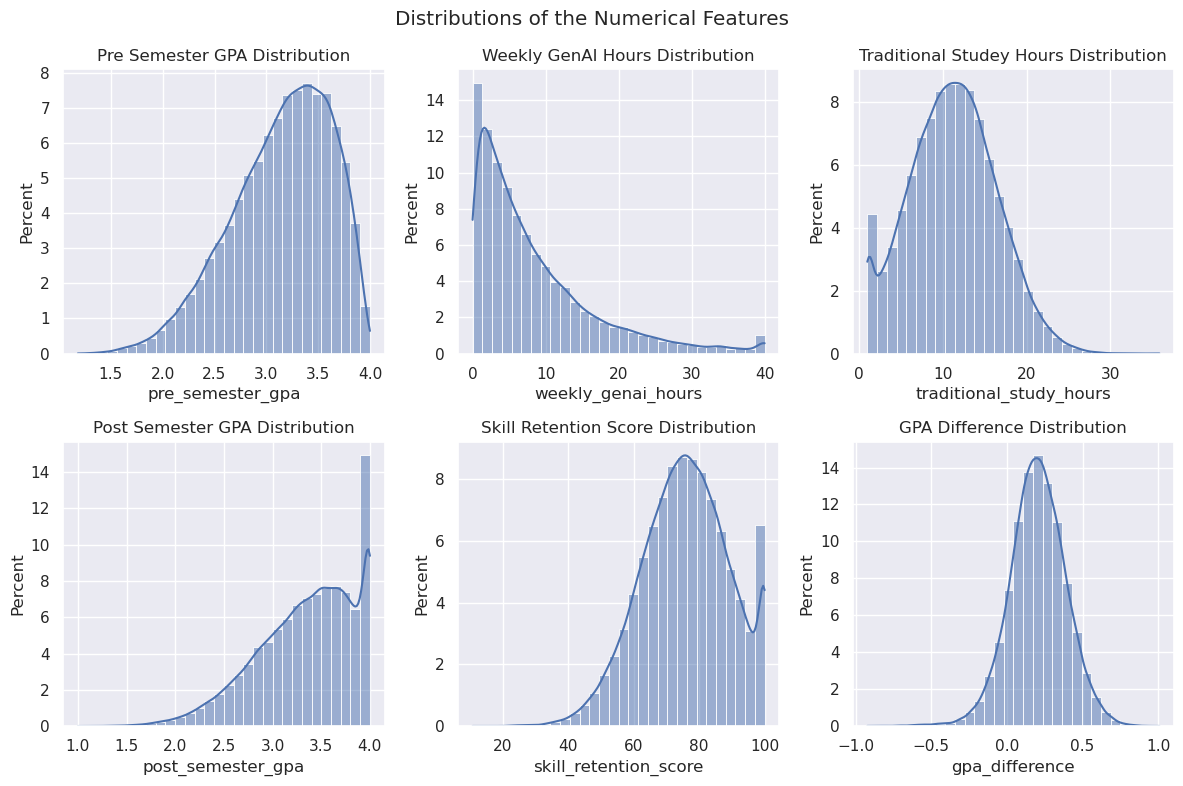

In [9]:
src.visualization.plot_univariate_distributions(df)

from the hist plot of the GPA difference we can see that the distribution of the GPA difference follows a normal distribution so it has one the assumptions of using linear regression as GLM.

In [10]:
for categorical_feature in categorical_features:
	print(utils.eda.category_percentage(df[categorical_feature]))
	print("-" * 40)

  major_category  percent
0           stem  % 30.12
1       business  % 25.08
2     humanities  % 19.99
3        medical  % 12.95
4           arts  % 11.87
----------------------------------------
  year_of_study  percent
0        junior  % 22.09
1      freshman  % 22.06
2        senior  % 21.27
3     sophomore  % 19.72
4      graduate  % 14.86
----------------------------------------
            primary_use_case  percent
0  debugging/troubleshooting  % 24.59
1       copywriting/drafting  % 24.02
2                   ideation  % 21.44
3        summarizing_reading  % 17.27
4   direct_answer_generation  % 12.68
----------------------------------------
  prompt_engineering_skill  percent
0                 beginner  % 36.99
1             intermediate  % 35.39
2                 advanced  % 27.62
----------------------------------------
    institutional_policy  percent
0  allowed_with_citation  % 50.45
1    actively_encouraged  % 29.98
2             strict_ban  % 19.58
----------------------

from the analyse above we can say:
- Based-on the dataset there is lower chance that students use AI for direct answer generation and the chance of using AI for debugging/troubleshooting or copywriting/drafting is more in among the students.

Which major use AI the most?

In [11]:
print("Weekly GenAI hours by major category:")
df.pivot_table(
    values="weekly_genai_hours",
    index="major_category",
    columns="year_of_study",
)

Weekly GenAI hours by major category:


year_of_study,freshman,graduate,junior,senior,sophomore
major_category,,,,,
arts,7.376326,7.351576,7.131103,7.303359,7.223841
business,8.220336,8.356439,8.339807,8.189125,8.295415
humanities,6.643767,6.867007,6.679696,6.779211,6.928092
medical,7.698955,7.823809,7.507156,7.513956,7.250650
stem,10.590061,10.114934,10.419695,10.626679,10.586208


this shows that STEM students are more likely to use AI more.

In [12]:
year_of_study_sorted = ["freshman", "sophomore", "junior", "senior", "graduate"]
df.pivot_table(
    values="traditional_study_hours",
    index="major_category",
    columns="year_of_study",
).loc[:, year_of_study_sorted].mean(axis=1)

major_category
arts          11.369427
business      11.203602
humanities    11.320793
medical       11.369779
stem          11.005075
dtype: float64

There is no specific chance that one major category study in traditional ways more than other major categories.

In [13]:
df.pivot_table(
    values="skill_retention_score",
    index="major_category",
    columns="year_of_study",
)

year_of_study,freshman,graduate,junior,senior,sophomore
major_category,,,,,
arts,74.155796,77.245972,74.657394,77.894512,74.827343
business,74.327489,77.065995,74.156531,77.188310,74.237916
humanities,73.677079,77.088007,74.104384,77.704130,74.167829
medical,74.732152,77.373820,74.642292,77.002450,74.276927
stem,75.758210,78.304008,75.848981,78.526936,75.944295


there is no sign for the difference in the chance of different students to have meaningful skill retention score more than other students.

In [14]:
print("Primary usage of each major category:")
df.pivot_table(
    values="weekly_genai_hours",
    index="major_category",
    columns="primary_use_case",
).style.highlight_max(axis=1, props="background-color: green; color: black")

Primary usage of each major category:


primary_use_case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
major_category,,,,,
arts,7.079039,7.600061,7.286136,7.669858,7.133167
business,8.086853,8.455982,8.397550,8.325226,7.977930
humanities,6.876253,6.375336,6.599464,6.742134,6.879968
medical,7.184280,7.591809,7.315104,7.673786,7.657968
stem,10.352187,10.445044,10.689452,10.479799,10.615806


In [15]:
print("traditional study hours:")
df.pivot_table(
    values="traditional_study_hours",
    index="major_category",
    columns="primary_use_case",
)

traditional study hours:


primary_use_case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
major_category,,,,,
arts,11.480311,11.176175,11.373050,10.875905,11.586916
business,11.115821,11.192232,11.207738,11.212835,11.274560
humanities,11.460557,11.175448,11.375610,11.154005,11.121037
medical,11.185907,11.536155,11.313291,11.301839,11.394329
stem,10.884931,11.050112,11.014767,10.947872,10.975083


In [16]:
df.groupby(by="primary_use_case")['gpa_difference'].mean()

primary_use_case
copywriting/drafting         0.200426
debugging/troubleshooting    0.249128
direct_answer_generation     0.133473
ideation                     0.199942
summarizing_reading          0.196886
Name: gpa_difference, dtype: float64

Based-on our data students whose primary use case from AI is debugging/troubleshooting are more likely to score better in exams and to improve their GPA at the end of the semester and students whose primary use case from AI is direct answer generation are less likely to make a big improvement in their GPAs at the end of the semester.

<Figure size 2000x1000 with 0 Axes>

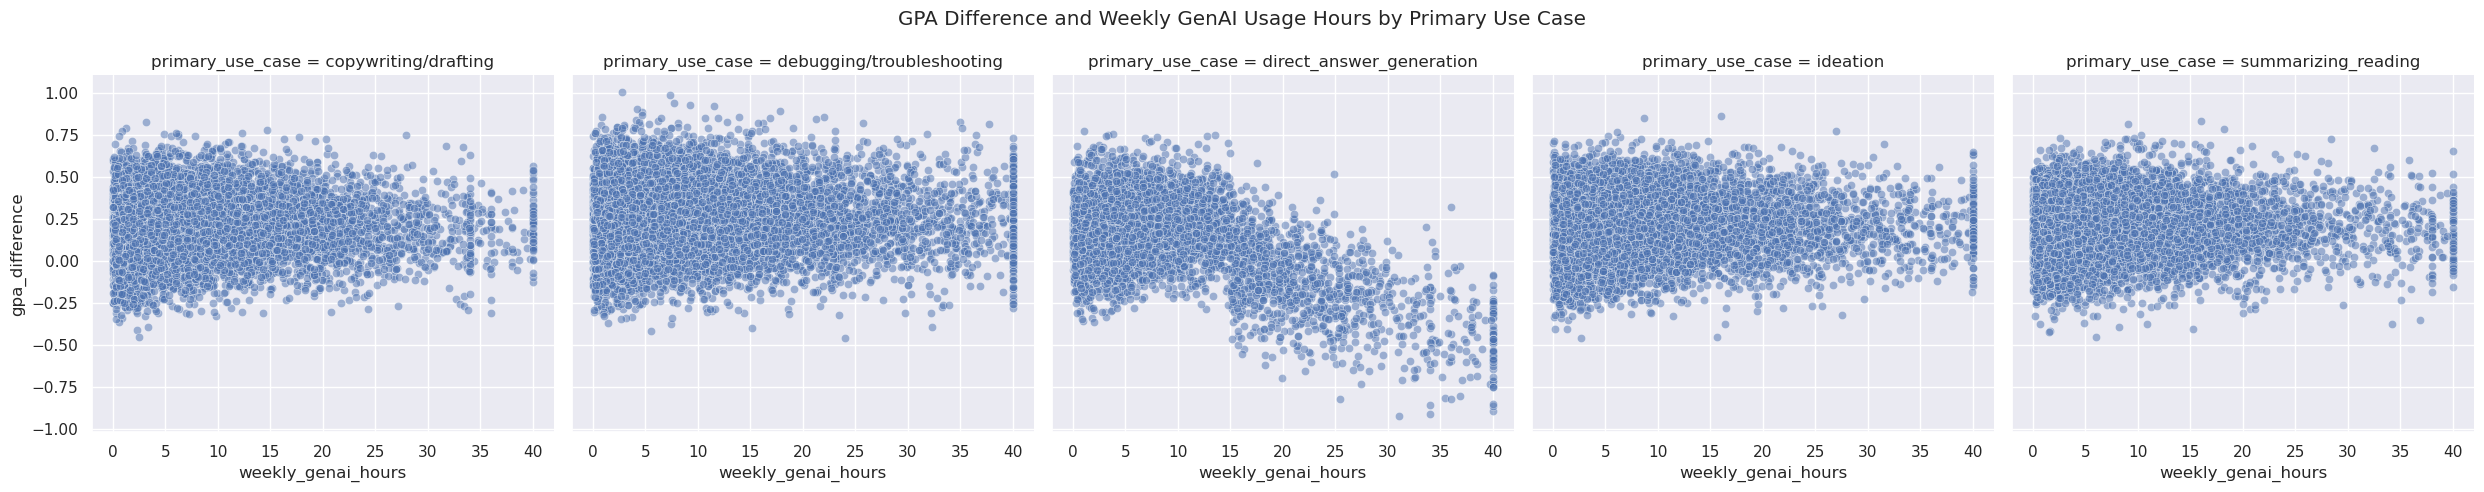

In [17]:
plt.figure(figsize=(20, 10))
sns.relplot(
	data=df,
    y="gpa_difference",
    x="weekly_genai_hours",
    col="primary_use_case",
    alpha=0.5,
)
plt.suptitle("GPA Difference and Weekly GenAI Usage Hours by Primary Use Case")
plt.tight_layout()

[Text(0.5, 1.0, 'GPA Difference by Weekly GenAI Hours for Students whose Primary Use Case is Direct Answer Generation')]

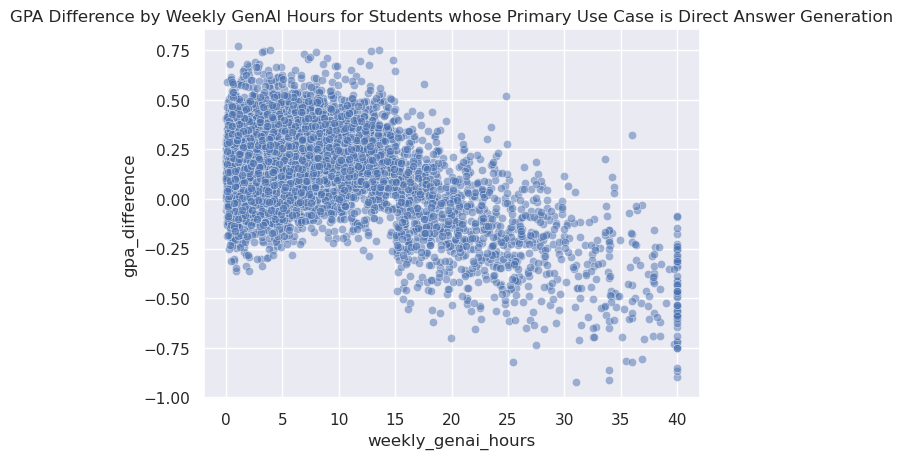

In [18]:
df_direct_answering = df[df['primary_use_case'] == "direct_answer_generation"]
ax = sns.scatterplot(
    data=df_direct_answering,
    y="gpa_difference",
    x="weekly_genai_hours",
    alpha=0.5
)
ax.set(
    title="GPA Difference by Weekly GenAI Hours for Students whose Primary Use Case is Direct Answer Generation"
)

So there is the pattern that students who uses AI for many hours for generate direct answers for their questions are more likely to experience lower GPA increase or more GPA drop at the end of the semester.

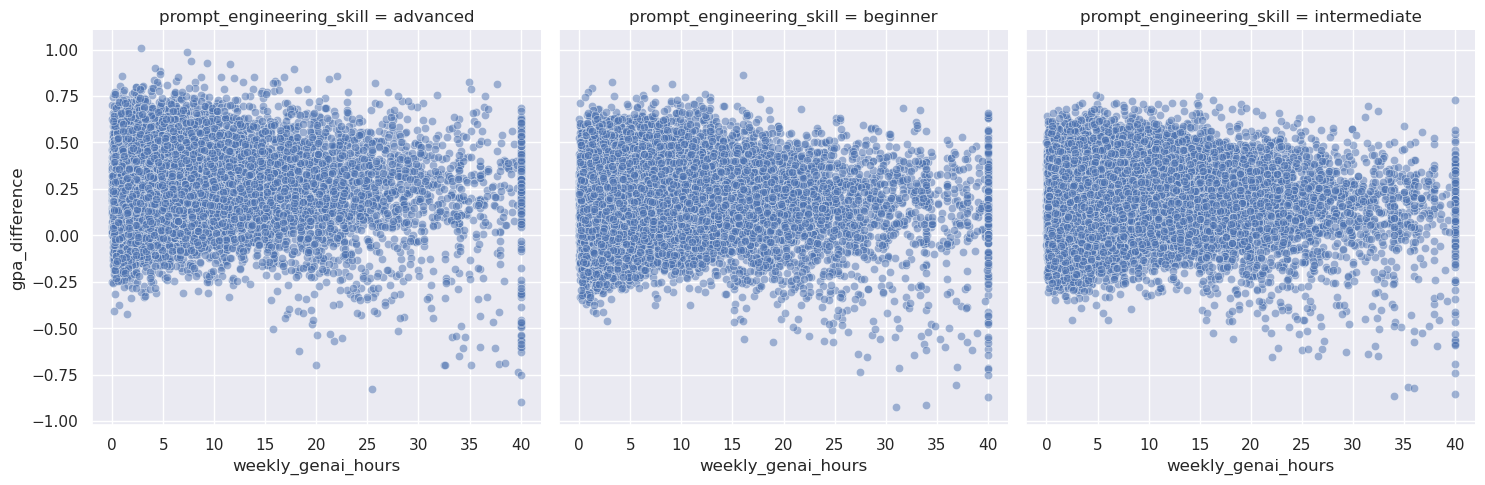

In [19]:
sns.relplot(
	data=df,
    y="gpa_difference",
    x="weekly_genai_hours",
    col="prompt_engineering_skill",
    alpha=0.5
)

In [20]:
df.pivot_table(
    values="skill_retention_score",
    index="major_category",
    columns="primary_use_case",
).style.highlight_min(axis=1, props="background-color: red; color: white").highlight_max(
        axis=1, props="background-color: green; color: black"
	)

primary_use_case,copywriting/drafting,debugging/troubleshooting,direct_answer_generation,ideation,summarizing_reading
major_category,,,,,
arts,75.580484,77.951072,74.633925,74.846402,75.497983
business,74.546163,76.938372,73.625743,75.500935,75.011123
humanities,75.110279,77.196420,74.148955,75.647890,74.657584
medical,74.707735,77.231092,73.925901,75.861707,75.523845
stem,75.912964,78.543921,73.037907,75.655056,75.172458


> **Pattern:** An important pattern identified that in all majors we can see that using AI to generate and give direct answers results in lower skill retention score that means giving direct answers from AI could damage your long-term skill retention. Another pattern that is visible is that using AI for debugging/troubleshooting has the least effect on the skill retention score and students whose primary use case from AI where debugging/troubleshooting did better in this part and maybe we can say using AI for debugging the things you already learned in traditional ways and to try solving problems more efficient results in better skill retention.

Text(0.5, 1.0, 'GPA Difference by Prompt Engineering Skill')

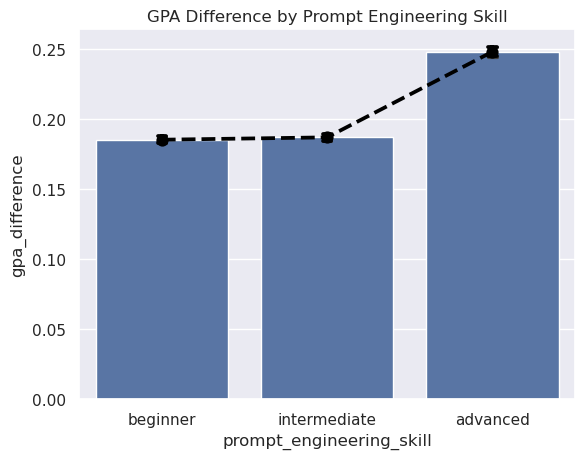

In [21]:
sns.barplot(
    data=df,
    x="prompt_engineering_skill",
    y="gpa_difference",
    capsize=0.05,
    order=["beginner", "intermediate", "advanced"]
)
sns.pointplot(
    data=df,
    x="prompt_engineering_skill",
    y="gpa_difference",
    capsize=0.05,
    color="black",
    markers="o",
    linestyles="--"
)

plt.title("GPA Difference by Prompt Engineering Skill")

We can see students with advanced prompt engineering skill are more likely to have better improvements in their gpa_difference. It can be derived that students with advanced prompt engineering skiils are more likely to work better in improving their GPA.

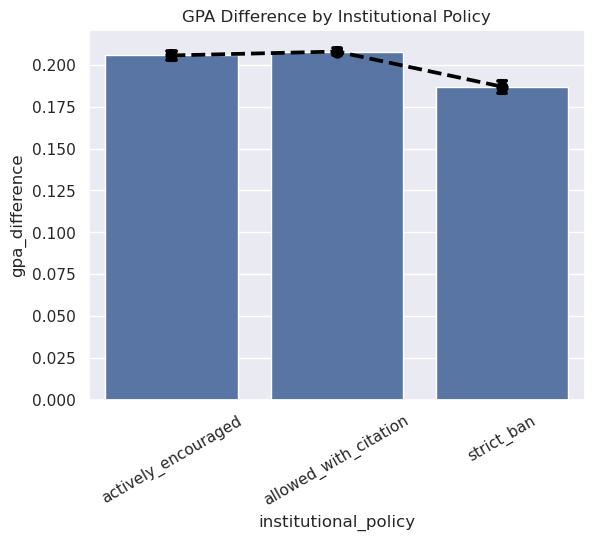

In [22]:
ax = sns.barplot(
    data=df,
    x="institutional_policy",
    y="gpa_difference",
    capsize=0.05
)
sns.pointplot(
    data=df,
    x="institutional_policy",
    y="gpa_difference",
    capsize=0.05,
    color="black",
    markers="o",
    linestyles="--",
    ax=ax
)

ax.set_title("GPA Difference by Institutional Policy")
ax.tick_params(axis="x", rotation=30)

students whose university have banned the usage of genai are less likely to improve their GPAs with respect to the university students with the actively_encouraged and allowed_with_citation institutional policy.

In [23]:
df.groupby(by="perceived_ai_dependency")['anxiety_level_during_exams'].mean()

perceived_ai_dependency
1     3.423388
2     3.741492
3     4.068334
4     4.390779
5     4.782061
6     5.187447
7     5.610337
8     6.042105
9     6.423280
10    6.915789
Name: anxiety_level_during_exams, dtype: float64

Text(0.5, 1.0, 'Anxiety Level During Exams by Perceived AI Dependency')

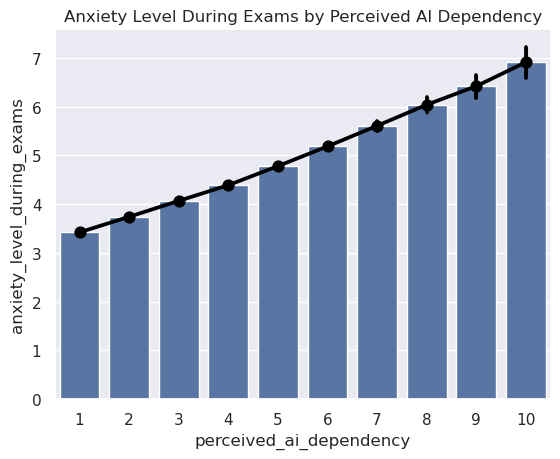

In [24]:
sns.barplot(
    data=df,
    x="perceived_ai_dependency",
    y="anxiety_level_during_exams"
)
sns.pointplot(
    data=df,
    x="perceived_ai_dependency",
    y="anxiety_level_during_exams",
    color="black"
)

plt.title("Anxiety Level During Exams by Perceived AI Dependency")

Another Pattern that we can extract from the data is that student that are more dependent on AI are more likely
to have higher level of anxienty during the exams.

[Text(0.5, 1.0, 'Perceived AI Dependency by Burnout Risk Level'),
 Text(0, 0.5, 'Perceived AI Dependency'),
 Text(0.5, 0, 'Burnout Risk Level')]

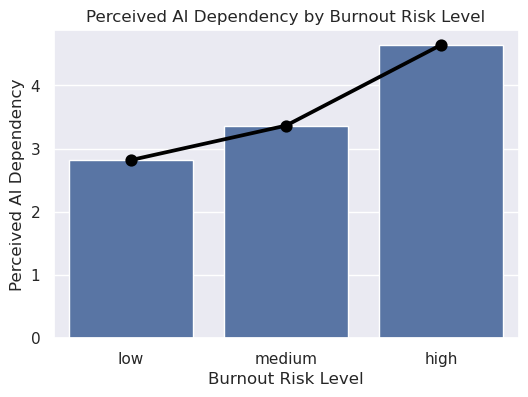

In [25]:
_, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    x=df.groupby(by="burnout_risk_level")["perceived_ai_dependency"].mean().index,
    y=df.groupby(by="burnout_risk_level")["perceived_ai_dependency"].mean().values,
    order=["low", "medium", "high"],
    ax=ax
)
sns.pointplot(
    x=df.groupby(by="burnout_risk_level")["perceived_ai_dependency"].mean().index,
    y=df.groupby(by="burnout_risk_level")["perceived_ai_dependency"].mean().values,
    order=["low", "medium", "high"],
    color="black",
    ax=ax
)

ax.set(
    title="Perceived AI Dependency by Burnout Risk Level",
    ylabel="Perceived AI Dependency",
    xlabel="Burnout Risk Level"
)

A pattern can be seen that students with higher perceived AI dependency are more likely to experience higher burnout risk level.

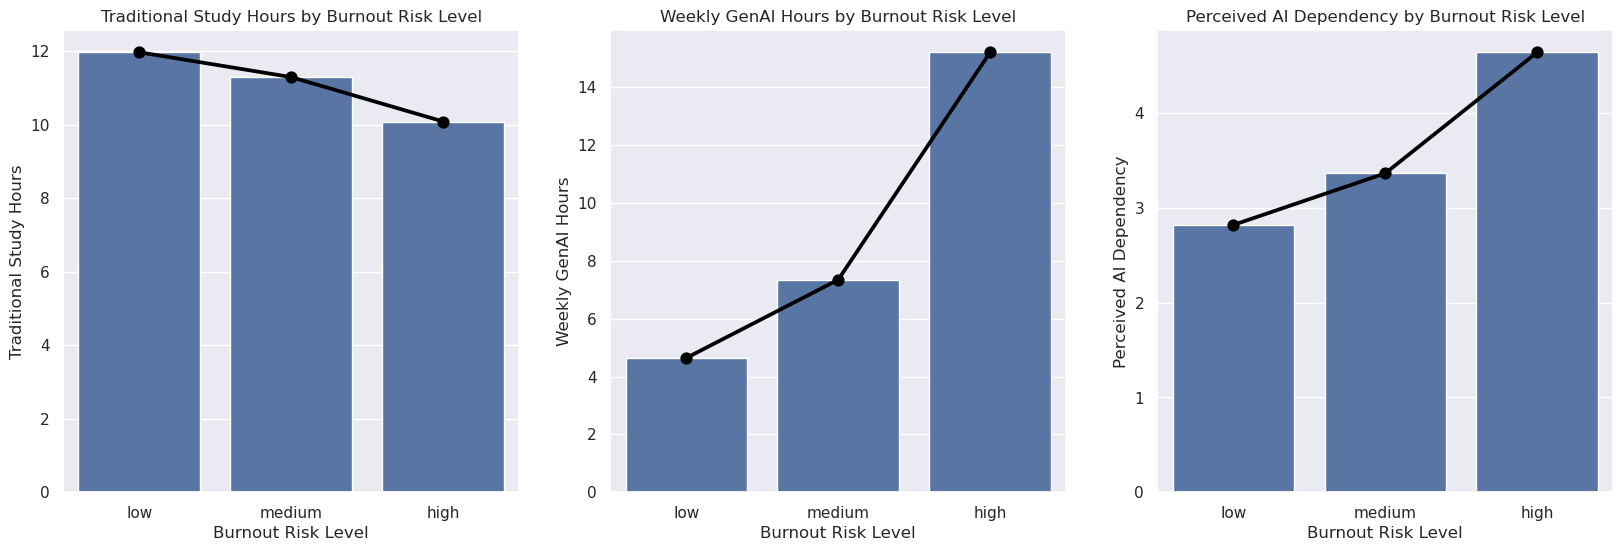

In [26]:
src.visualization.plot_variables_by_burnout_risk_level(df)

We can see this pattern that students who have lower traditional study hours are more likely to have higher burnout risk level, students who have higher weekly GenAI hours are more likely to have higher burnout risk level, and students who are more dependent on AI are more likely to have higher burnout risk level.

**In general based-on the dataset students with less traditional study hours that using AI more than other students are more likely to have higher level of burnout.**

> There is a pattern detected that students with higher burnout risk levels are less likely to have more traditional study hours, more likely to have significantly higher weekly GenAI hours, and more likely to have more dependency on AI.

# Encoding Categorical Variables:

In [27]:
features_encoded = src.feature_engineering.encode_categorical_variables(df)

X = features_encoded.to_numpy()
y = df['post_semester_gpa'].to_numpy()

features_encoded.head()

,major_category_humanities,major_category_medical,major_category_business,major_category_stem,year_of_study,pre_semester_gpa,weekly_genai_hours,primary_use_case_copywriting/drafting,primary_use_case_ideation,primary_use_case_summarizing_reading,...,prompt_engineering_skill,tool_diversity,paid_subscription,traditional_study_hours,perceived_ai_dependency,institutional_policy_allowed_with_citation,institutional_policy_strict_ban,anxiety_level_during_exams,skill_retention_score,burnout_risk_level
0,1,0,0,0,3,2.418,23.31,1,0,0,...,0,1,True,8.13,5,1,0,6,86.44,2
1,0,1,0,0,2,3.821,1.12,0,1,0,...,2,5,False,16.65,3,1,0,9,69.39,0
2,0,0,1,0,0,3.398,21.26,0,0,1,...,0,2,False,10.35,5,0,1,9,73.93,1
3,0,0,1,0,3,3.789,1.82,1,0,0,...,1,4,False,15.23,2,1,0,2,63.58,1
4,0,0,0,1,1,3.635,9.29,0,0,0,...,2,4,False,12.55,4,1,0,4,100.00,1


After encoding we have 21 features available for the prediction task.

Text(0.5, 1.0, 'Correlation Matrix')

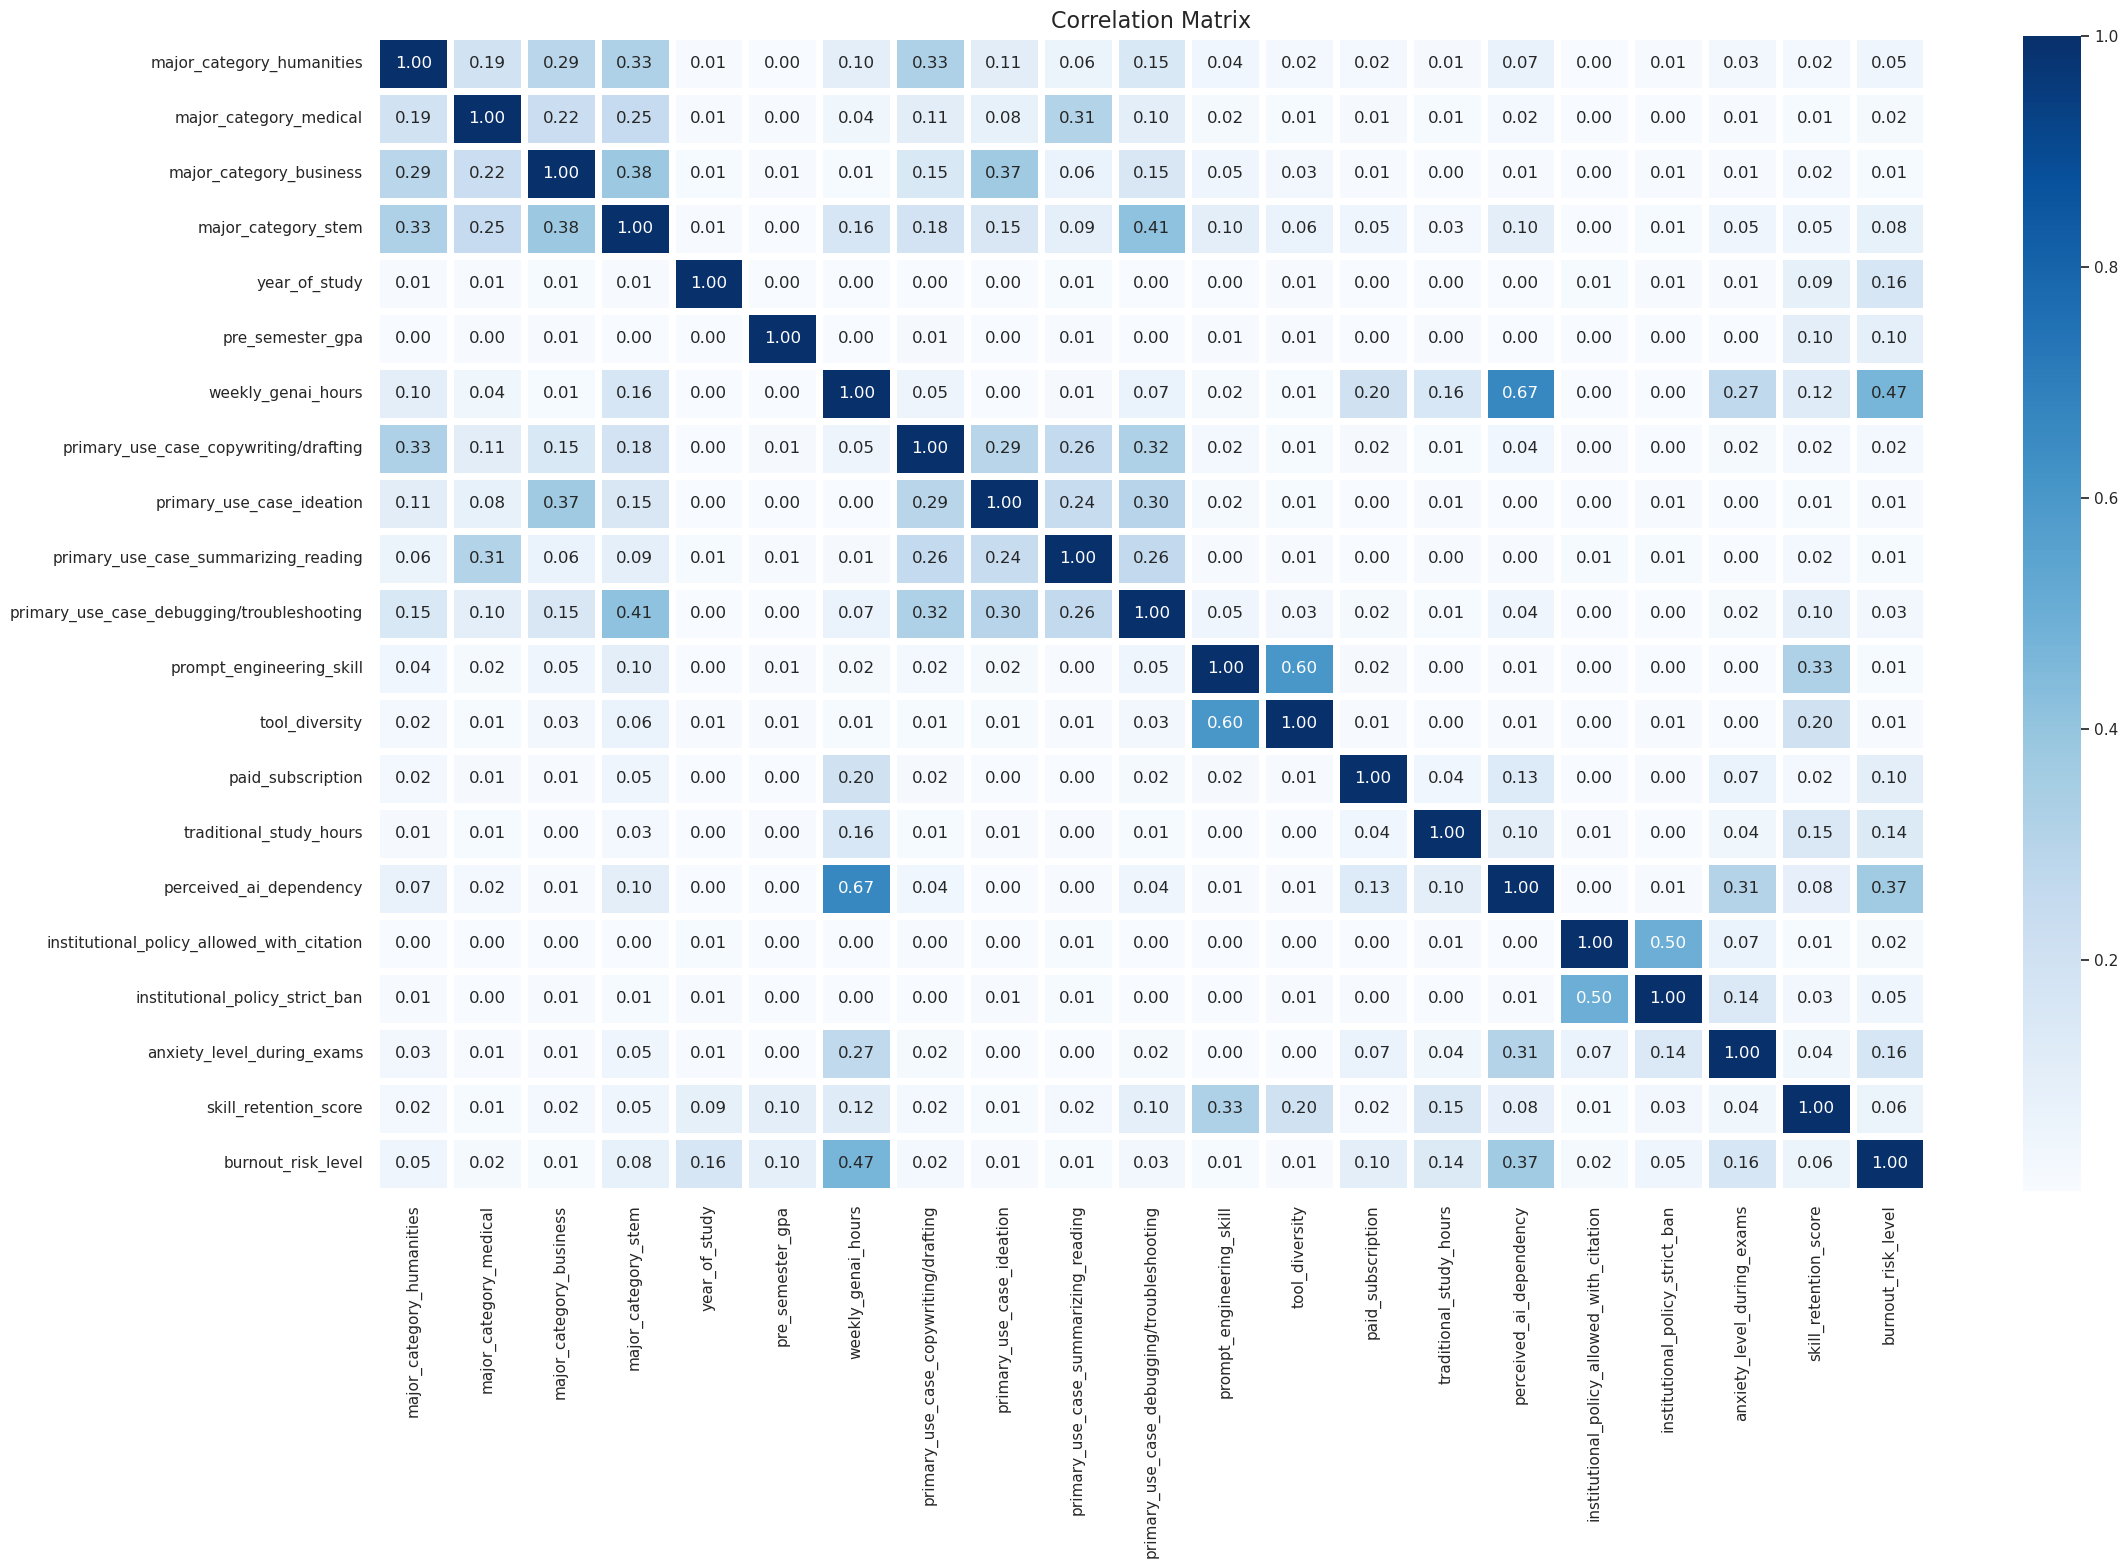

In [28]:
plt.figure(figsize=(25, 15))

sns.heatmap(
    data=abs(features_encoded.corr()),
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=5,
)
plt.title("Correlation Matrix", fontsize=16)

One of the most important assumptions of the linear regression model is that features should not be highly correlated with each other and multicolinearity is a big problem.

In this dataset we see some highly correlated features. `perceived_ai_dependency, weekly_genai_hours, and burnout_risk_level` are highly correlated to each other. `tool_diversity, prompt_engineering_skill, and skill_retention_score` are also correlated with each other.

In [29]:
# saving the processed data
np.savez(file="../data/processed/processed_data.npz", X=X, y=y, features=features_encoded.columns)

In [30]:
# making continuous features polynomial features
poly = ColumnTransformer(
    transformers=[
        ("poly", PolynomialFeatures(degree=5), ["weekly_genai_hours", "traditional_study_hours", "skill_retention_score"])
	]
)


features_poly = pd.concat(
    [
        features_encoded,
        pd.DataFrame(
			data=poly.fit_transform(features_encoded),
			columns=[f"poly_{i}" for i in range(1, 57)]
		)
	],
	axis=1
).drop(["weekly_genai_hours", "traditional_study_hours", "skill_retention_score"], axis=1)

# saving the dataset
np.savez_compressed(file="../data/processed/polynomial_features.npz", features_poly=features_poly)